In [12]:
!pip install timm -q

In [17]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms

import os
import re
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import timm

In [1]:
import kagglehub
import os

path = kagglehub.dataset_download("mariafrenti/age-prediction")

print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 2.03G/2.03G [00:20<00:00, 108MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mariafrenti/age-prediction/versions/3
['age_prediction_up', '20-50']


In [27]:
import os

csv_files = []
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = " " * 4 * level
    print(indent + os.path.basename(root) + "/")

    subindent = " " * 4 * (level + 1)
    for f in files[:5]:
        print(subindent + f)
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")
for f in csv_files:
    print(f)

3/
    age_prediction_up/
        age_prediction/
            test/
                056/
                    29635.jpg
                    29504.jpg
                    10908.jpg
                    13368.jpg
                    19972.jpg
                057/
                    19122.jpg
                    15186.jpg
                    26247.jpg
                    17514.jpg
                    20951.jpg
                059/
                    10653.jpg
                    9052.jpg
                    27690.jpg
                    38343.jpg
                    763.jpg
                042/
                    7010.jpg
                    33345.jpg
                    21730.jpg
                    41620.jpg
                    14931.jpg
                004/
                    6661.jpg
                    8913.jpg
                    9590.jpg
                    9683.jpg
                    7976.jpg
                080/
                    44281.jpg
                    13529.jpg
     

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

age_model_path = "/content/best_age_efficientnet_b4.pth"

Using: cuda


In [28]:
import os
import pandas as pd
import random
import matplotlib.pyplot as plt
from PIL import Image
import torch

def get_real_age_from_folder(img_path):
    folder_name = os.path.basename(os.path.dirname(img_path))

    # examples: "056", "30", "100"
    if folder_name.isdigit():
        return int(folder_name)

    return None

In [32]:
image_paths = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(root, file))

print("Number of images:", len(image_paths))
print("Example:", image_paths[0])

Number of images: 273640
Example: /root/.cache/kagglehub/datasets/mariafrenti/age-prediction/versions/3/age_prediction_up/age_prediction/test/056/29635.jpg


In [33]:
for img_path in image_paths[:10]:
    print(img_path)
    print("Real age:", get_real_age_from_folder(img_path))
    print("-" * 50)

/root/.cache/kagglehub/datasets/mariafrenti/age-prediction/versions/3/age_prediction_up/age_prediction/test/056/29635.jpg
Real age: 56
--------------------------------------------------
/root/.cache/kagglehub/datasets/mariafrenti/age-prediction/versions/3/age_prediction_up/age_prediction/test/056/29504.jpg
Real age: 56
--------------------------------------------------
/root/.cache/kagglehub/datasets/mariafrenti/age-prediction/versions/3/age_prediction_up/age_prediction/test/056/10908.jpg
Real age: 56
--------------------------------------------------
/root/.cache/kagglehub/datasets/mariafrenti/age-prediction/versions/3/age_prediction_up/age_prediction/test/056/13368.jpg
Real age: 56
--------------------------------------------------
/root/.cache/kagglehub/datasets/mariafrenti/age-prediction/versions/3/age_prediction_up/age_prediction/test/056/19972.jpg
Real age: 56
--------------------------------------------------
/root/.cache/kagglehub/datasets/mariafrenti/age-prediction/versions/3/

In [15]:
state_dict = torch.load(
    age_model_path,
    map_location=device,
    weights_only=False
)

print("Checkpoint type:", type(state_dict))

print("Important layer shapes:")
print("shared.0.weight:", state_dict["shared.0.weight"].shape)
print("shared.4.weight:", state_dict["shared.4.weight"].shape)
print("age_head.weight:", state_dict["age_head.weight"].shape)
print("bin_head.weight:", state_dict["bin_head.weight"].shape)

Checkpoint type: <class 'collections.OrderedDict'>
Important layer shapes:
shared.0.weight: torch.Size([512, 1792])
shared.4.weight: torch.Size([256, 512])
age_head.weight: torch.Size([1, 256])
bin_head.weight: torch.Size([7, 256])


In [16]:
age_model_path = "/content/best_age_efficientnet_b4.pth"

state_dict = torch.load(
    age_model_path,
    map_location=device,
    weights_only=False
)

In [18]:
class AgeEfficientNetB4(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b4",
            pretrained=False,
            num_classes=0
        )

        self.shared = nn.Sequential(
            nn.Linear(1792, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.age_head = nn.Linear(256, 1)
        self.bin_head = nn.Linear(256, 7)

    def forward(self, x):
        x = self.backbone(x)
        x = self.shared(x)

        age = self.age_head(x)
        age_bin = self.bin_head(x)

        return age, age_bin

In [19]:
age_model = AgeEfficientNetB4().to(device)

age_model.load_state_dict(state_dict, strict=True)

age_model.eval()

print("Age model loaded correctly")

Age model loaded correctly


Number of images: 273640
Example: /root/.cache/kagglehub/datasets/mariafrenti/age-prediction/versions/3/age_prediction_up/age_prediction/test/056/29635.jpg


In [20]:
age_transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [21]:
def predict_age(img_path):
    img = Image.open(img_path).convert("RGB")

    input_tensor = age_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        age_output, bin_output = age_model(input_tensor)

    predicted_age = age_output.item()

    return predicted_age

In [34]:
results = []

# You can increase this later, for example 500 or 1000
test_paths = random.sample(image_paths, min(300, len(image_paths)))

for img_path in test_paths:
    real_age = get_real_age_from_folder(img_path)

    if real_age is None:
        continue

    pred_age = predict_age(img_path)

    results.append({
        "image": os.path.basename(img_path),
        "path": img_path,
        "real_age": real_age,
        "predicted_age": pred_age,
        "error": abs(real_age - pred_age)
    })

df_results = pd.DataFrame(results)

display(df_results.head())

print("Number of tested images:", len(df_results))
print("MAE:", round(df_results["error"].mean(), 2))

,image,path,real_age,predicted_age,error
0,35952.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,27,27.581320,0.581320
1,9740.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,31,23.375536,7.624464
2,33674.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,13,18.634230,5.634230
3,30620.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,66,45.606525,20.393475
4,172233.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,35,32.458054,2.541946


Number of tested images: 300
MAE: 7.98


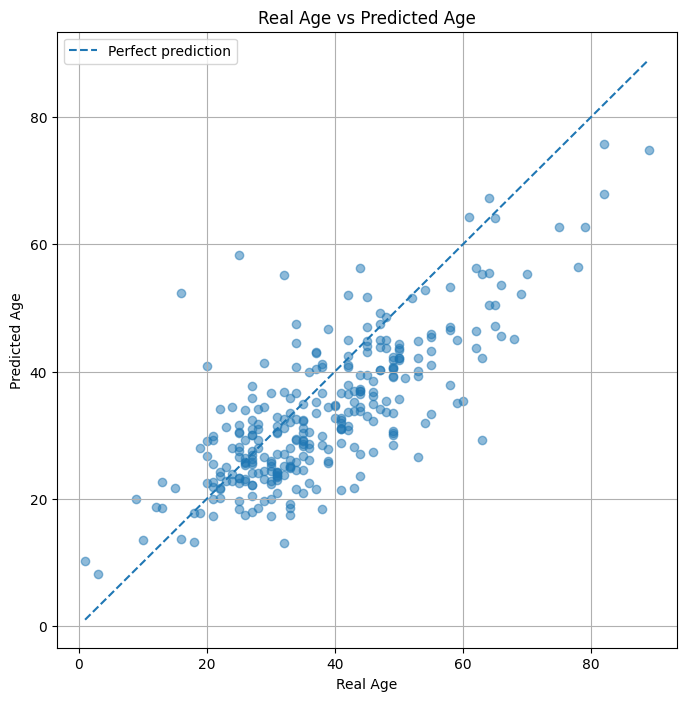

In [35]:
plt.figure(figsize=(8, 8))

plt.scatter(
    df_results["real_age"],
    df_results["predicted_age"],
    alpha=0.5
)

min_age = min(df_results["real_age"].min(), df_results["predicted_age"].min())
max_age = max(df_results["real_age"].max(), df_results["predicted_age"].max())

plt.plot(
    [min_age, max_age],
    [min_age, max_age],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Real Age")
plt.ylabel("Predicted Age")
plt.title("Real Age vs Predicted Age")
plt.legend()
plt.grid(True)
plt.show()

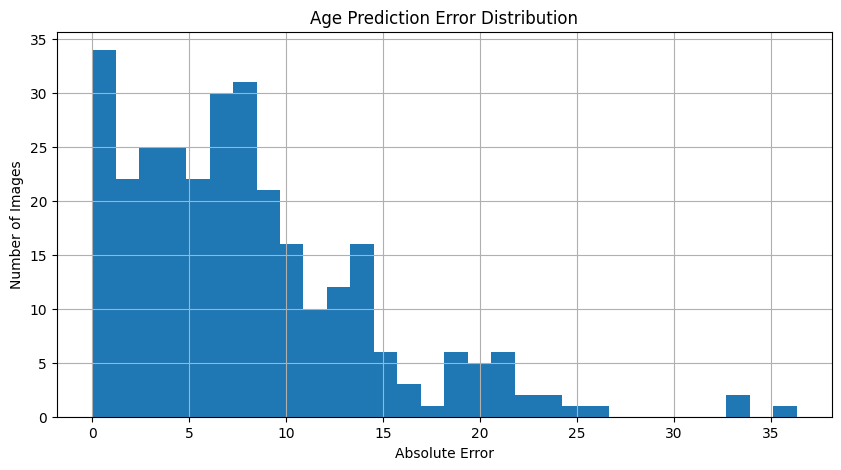

In [36]:
plt.figure(figsize=(10, 5))

plt.hist(df_results["error"], bins=30)

plt.xlabel("Absolute Error")
plt.ylabel("Number of Images")
plt.title("Age Prediction Error Distribution")
plt.grid(True)
plt.show()

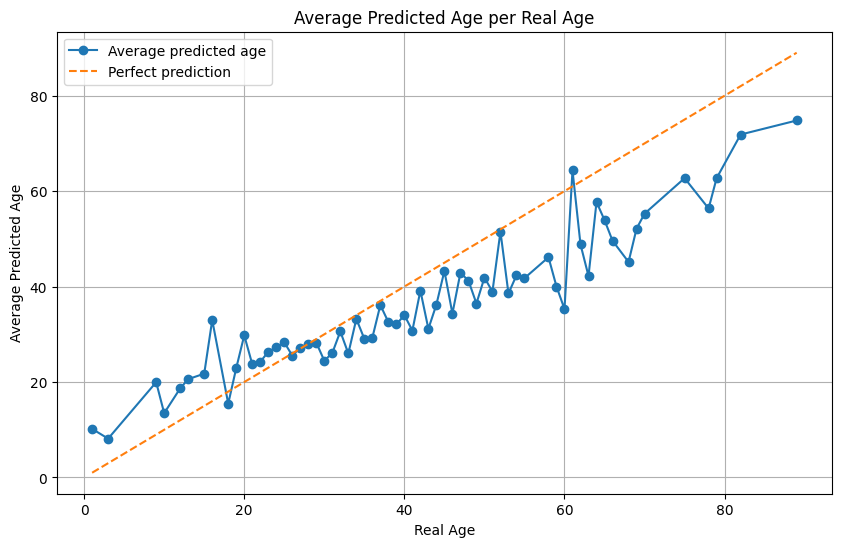

In [37]:
avg_by_age = df_results.groupby("real_age")["predicted_age"].mean().reset_index()

plt.figure(figsize=(10, 6))

plt.plot(
    avg_by_age["real_age"],
    avg_by_age["predicted_age"],
    marker="o",
    label="Average predicted age"
)

plt.plot(
    avg_by_age["real_age"],
    avg_by_age["real_age"],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Real Age")
plt.ylabel("Average Predicted Age")
plt.title("Average Predicted Age per Real Age")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
print("Best predictions:")
display(df_results.sort_values("error").head(10))

print("Worst predictions:")
display(df_results.sort_values("error", ascending=False).head(10))

Best predictions:


,image,path,real_age,predicted_age,error
115,47431.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,28,28.001295,0.001295
263,14321.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,27,26.929487,0.070513
186,20878.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,24,23.928827,0.071173
50,93832.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,35,34.913109,0.086891
91,38977.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,45,44.850342,0.149658
189,20217.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,26,25.779531,0.220469
151,145030.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,23,22.732868,0.267132
286,120369.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,18,17.731524,0.268476
16,18954.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,22,21.715149,0.284851
178,171390.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,26,25.595900,0.404100


Worst predictions:


,image,path,real_age,predicted_age,error
153,33057.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,16,52.341728,36.341728
220,6220.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,63,29.207220,33.792780
174,143922.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,25,58.380684,33.380684
7,10604.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,53,26.518099,26.481901
124,165706.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,60,35.293884,24.706116
99,112667.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,59,35.090179,23.909821
5,153639.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,32,55.201172,23.201172
239,36428.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,68,45.158318,22.841682
292,12595.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,54,31.899618,22.100382
195,96602.jpg,/root/.cache/kagglehub/datasets/mariafrenti/ag...,78,56.371635,21.628365


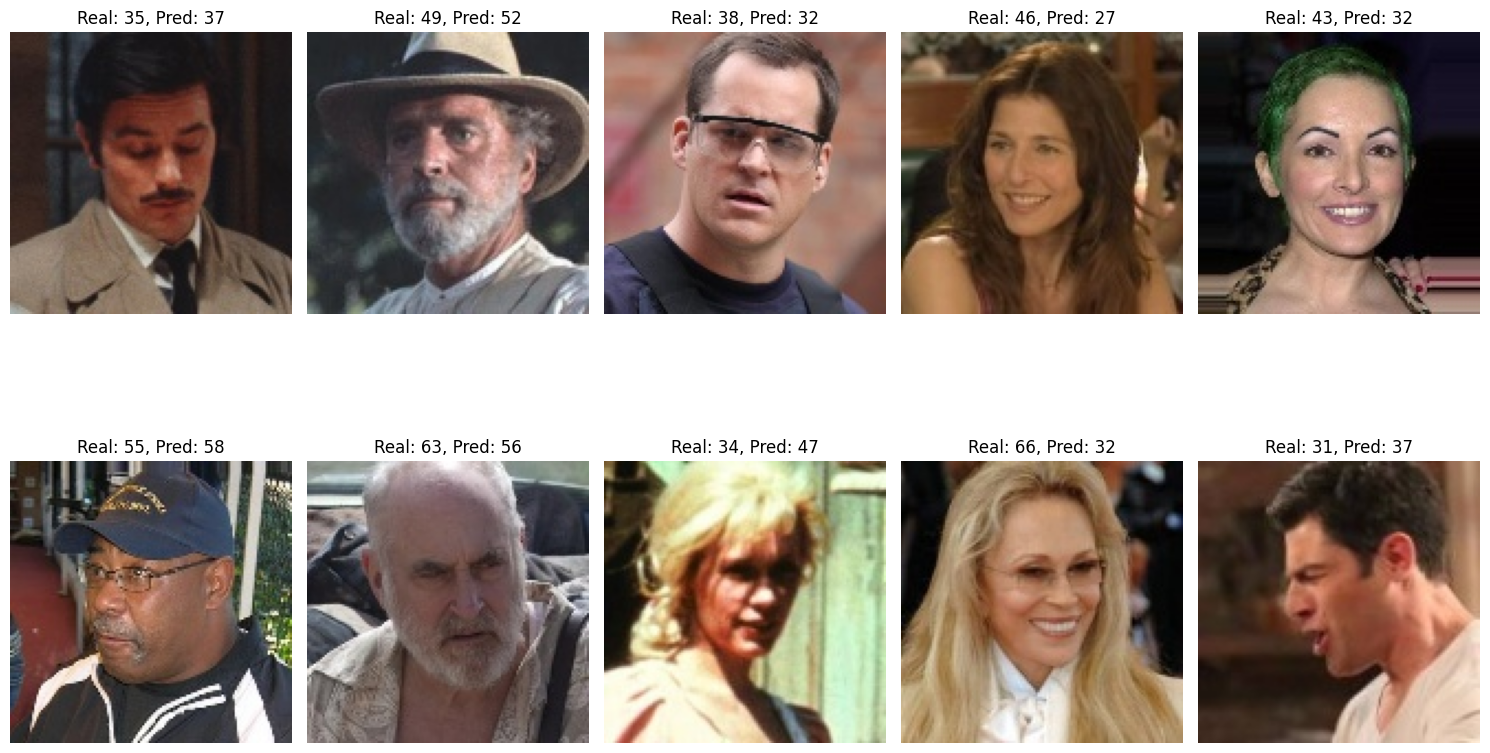

In [40]:
random_sample_images = random.sample(image_paths, 10)

plt.figure(figsize=(15, 10))
for i, img_path in enumerate(random_sample_images):
    real_age = get_real_age_from_folder(img_path)
    if real_age is None:
        continue
    predicted_age = predict_age(img_path)

    img = Image.open(img_path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Real: {real_age}, Pred: {predicted_age:.0f}")
    plt.axis("off")

plt.tight_layout()
plt.show()